<a href="https://colab.research.google.com/github/elio12162030/IS484-Practica001-Jueves-Huaman/blob/main/Ejercicio1_Credito_Aquino.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Ejercicio 1: Evaluación de solicitud de crédito bancario

**Estudiante:** Elio Huaman Aquino  
**Curso:** Inteligencia Artificial I (IS-484)

### Ficha PEAS

| Elemento | Descripción |
|---|---|
| **Percepción (S)** | Ingreso mensual, monto solicitado e indicador de historial moroso. |
| **Acciones (A)** | Aprobar, aprobar con condiciones o rechazar la solicitud. |
| **Entorno (E)** | Plataforma de créditos del banco, solicitantes, base de historial crediticio y políticas de riesgo. |
| **Objetivo** | Otorgar créditos viables, reducir la morosidad y responder de manera coherente a cada solicitud. |
| **Medida de desempeño (P)** | Baja tasa de incumplimiento, pocos falsos rechazos, tiempo corto de evaluación y cumplimiento de las políticas del banco. |

### Justificación de las reglas

Se aplican las siguientes reglas: sin historial moroso se aprueba cuando la relación monto/ingreso es menor o igual a 0.30, se aprueba con condiciones si es mayor a 0.30 y menor o igual a 0.50, y se rechaza por encima de 0.50. Si existe historial moroso, solo una relación menor o igual a 0.30 permite una aprobación condicionada; una relación mayor se rechaza. Estas reglas reducen la exposición del banco al combinar capacidad de pago e historial, sin descartar automáticamente todos los casos de bajo riesgo relativo.

### Código

In [4]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    # Evalúa una solicitud y retorna una tupla (acción, motivo).
    if ingreso_mensual <= 0:
        return "rechazar", "el ingreso mensual debe ser mayor que cero"
    if monto_solicitado <= 0:
        return "rechazar", "el monto solicitado debe ser mayor que cero"
    if not isinstance(tiene_historial_moroso, bool):
        return "rechazar", "el historial moroso debe indicarse con True o False"

    relacion = monto_solicitado / ingreso_mensual

    if tiene_historial_moroso:
        if relacion <= 0.30:
            return (
                "aprobar con condiciones",
                f"relación monto/ingreso de {relacion:.4f}, pero registra historial moroso",
            )
        return (
            "rechazar",
            f"relación monto/ingreso de {relacion:.4f} y registra historial moroso",
        )

    if relacion <= 0.30:
        return "aprobar", f"relación monto/ingreso de {relacion:.4f} y sin historial moroso"
    if relacion <= 0.50:
        return (
            "aprobar con condiciones",
            f"relación monto/ingreso de {relacion:.4f}; se requiere garantía o evaluación adicional",
        )
    return "rechazar", f"relación monto/ingreso de {relacion:.4f}, superior a 0.50"

### Simulación y pruebas

In [6]:
casos_credito = [
    # ingreso, monto, historial; incluye los bordes 0.30 y 0.50
    (4000, 1200, False),  # relación 0.30: aprobar
    (4000, 1201, False),  # apenas mayor a 0.30: aprobar con condiciones
    (4000, 2000, False),  # relación 0.50: aprobar con condiciones
    (4000, 2001, False),  # apenas mayor a 0.50: rechazar
    (5000, 1000, True),   # moroso y relación baja: aprobar con condiciones
    (5000, 2000, True),   # moroso y relación alta: rechazar
]

for ingreso, monto, moroso in casos_credito:
    accion, motivo = agente_credito(ingreso, monto, moroso)
    relacion = monto / ingreso
    print(
        f"Ingreso=S/ {ingreso:,.0f} | Monto=S/ {monto:,.0f} | "
        f"Relación={relacion:.4f} | Moroso={moroso} -> {accion}: {motivo}"
    )

Ingreso=S/ 4,000 | Monto=S/ 1,200 | Relación=0.3000 | Moroso=False -> aprobar: relación monto/ingreso de 0.3000 y sin historial moroso
Ingreso=S/ 4,000 | Monto=S/ 1,201 | Relación=0.3003 | Moroso=False -> aprobar con condiciones: relación monto/ingreso de 0.3003; se requiere garantía o evaluación adicional
Ingreso=S/ 4,000 | Monto=S/ 2,000 | Relación=0.5000 | Moroso=False -> aprobar con condiciones: relación monto/ingreso de 0.5000; se requiere garantía o evaluación adicional
Ingreso=S/ 4,000 | Monto=S/ 2,001 | Relación=0.5002 | Moroso=False -> rechazar: relación monto/ingreso de 0.5002, superior a 0.50
Ingreso=S/ 5,000 | Monto=S/ 1,000 | Relación=0.2000 | Moroso=True -> aprobar con condiciones: relación monto/ingreso de 0.2000, pero registra historial moroso
Ingreso=S/ 5,000 | Monto=S/ 2,000 | Relación=0.4000 | Moroso=True -> rechazar: relación monto/ingreso de 0.4000 y registra historial moroso


### Visualización

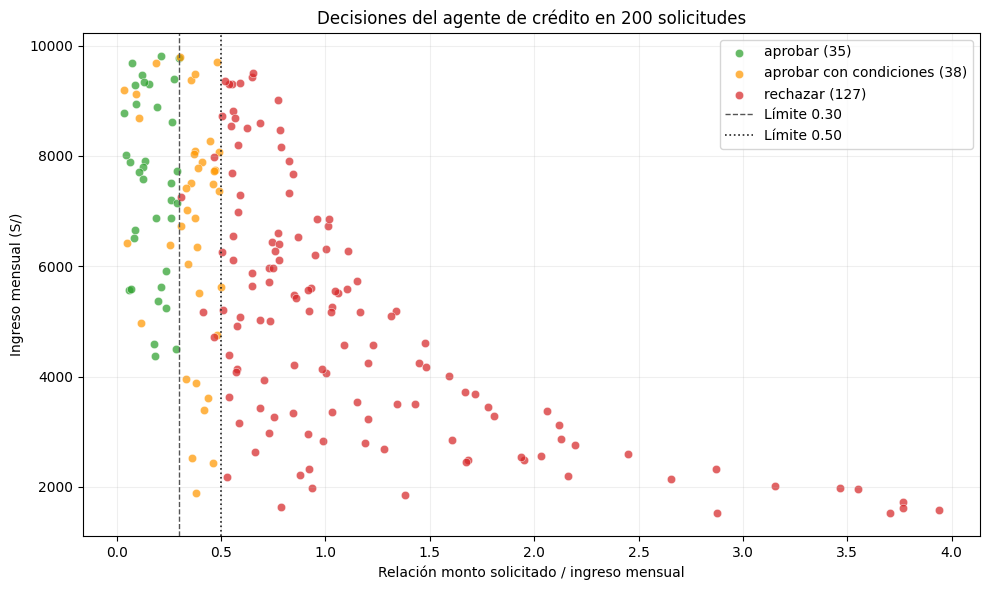

Resumen de decisiones: {'aprobar con condiciones': 38, 'rechazar': 127, 'aprobar': 35}


In [7]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(484)  # semilla para reproducir los resultados
n = 200
ingresos = rng.integers(1500, 10001, size=n)
montos = rng.integers(300, 7001, size=n)
historiales = rng.choice([False, True], size=n, p=[0.80, 0.20])
relaciones = montos / ingresos

decisiones = [
    agente_credito(int(i), int(m), bool(h))[0]
    for i, m, h in zip(ingresos, montos, historiales)
]

colores = {
    "aprobar": "#2ca02c",
    "aprobar con condiciones": "#ff9800",
    "rechazar": "#d62728",
}

plt.figure(figsize=(10, 6))
for decision, color in colores.items():
    mascara = np.array(decisiones) == decision
    plt.scatter(
        relaciones[mascara],
        ingresos[mascara],
        c=color,
        label=f"{decision} ({mascara.sum()})",
        alpha=0.72,
        edgecolors="white",
        linewidths=0.4,
    )

plt.axvline(0.30, color="#555555", linestyle="--", linewidth=1, label="Límite 0.30")
plt.axvline(0.50, color="#222222", linestyle=":", linewidth=1.2, label="Límite 0.50")
plt.title("Decisiones del agente de crédito en 200 solicitudes")
plt.xlabel("Relación monto solicitado / ingreso mensual")
plt.ylabel("Ingreso mensual (S/)")
plt.grid(alpha=0.20)
plt.legend()
plt.tight_layout()
plt.show()

from collections import Counter
print("Resumen de decisiones:", dict(Counter(decisiones)))